# 10 — Ablation ladder and performance versus predictor count

**Purpose.** Build the model up in controlled steps — persistence, local raw wind, local engineered
predictors, plus Ganos, plus the raw regional components, full set — and add the neighbour-only and
physics-guided variants, all scored out of sample in the rolling-origin protocol with the
hyperparameters selected for each outer year.

**Answers:** Reviewer 4 comment 8; Reviewer 3 comment 3.
**Inputs:** `df_final_features_causal.feather`, `rolling_origin_params.json`.
**Outputs:** `tables/T2_ablation.csv`, `tables/S_ablation_by_year.csv`, `figS5_ablation_featurecount`.
**Runtime:** ~10–20 min.

In [1]:
# --- Setup: Drive, paths, shared helpers -------------------------------------------------------
import os, sys, json, time, warnings, subprocess
warnings.filterwarnings('ignore')
try:
    from google.colab import drive
    drive.mount('/content/drive')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'optuna', 'shap', 'scienceplots',
                    'ephem', 'catboost', 'lightgbm'], check=False)
except Exception:
    pass
_BASE = os.environ.get('SARKOY_BASE', '/content/drive/MyDrive/windforecast_rev1/')
sys.path.insert(0, os.path.join(_BASE, 'revision'))
if not os.path.exists(os.path.join(_BASE, 'revision', 'revision_utils.py')):
    raise FileNotFoundError('Copy revision_utils.py into ' + os.path.join(_BASE, 'revision') + ' first.')
import revision_utils as ru
import numpy as np, pandas as pd, matplotlib.pyplot as plt
BASE, REV, IN_COLAB, FAST = ru.get_paths()
ru.set_style()
RES = ru.Results(REV)
RES.path = REV + 'results_10.json'
GPU = ru.has_gpu()
try:
    from IPython.display import display
except Exception:
    display = print
print('BASE:', BASE, '| REV:', REV, '| GPU:', GPU, '| FAST (smoke test):', FAST)
print(ru.log_versions(REV))


Mounted at /content/drive
BASE: /content/drive/MyDrive/windforecast_rev1/ | REV: /content/drive/MyDrive/windforecast_rev1/revision/ | GPU: True | FAST (smoke test): False
{'python': '3.13.15', 'numpy': '2.1.3', 'pandas': '2.2.3', 'sklearn': '1.6.1', 'scipy': '1.16.3', 'xgboost': '3.4.1', 'lightgbm': '4.6.0', 'catboost': '1.2.10', 'optuna': '5.0.0', 'shap': '0.52.0', 'statsmodels': '0.15.0', 'matplotlib': '3.10.0', 'seaborn': '0.13.2', 'pyarrow': '23.0.1', 'ephem': '4.2.1', 'tensorflow': '2.20.0', 'gpu': True}


In [2]:
# --- Setup: feature sets and the hyperparameters of each outer year -----------------------------
df = ru.load_matrix(BASE, REV, 'causal')
X = ru.get_X(df); y = df[ru.TARGET]; ok = df['target_observed'].astype(bool)
params_all = json.load(open(REV + 'rolling_origin_params.json'))
YEARS = sorted(int(k) for k in params_all)
SETS = ru.ablation_sets(ru.FEATURES_559)
TOPK = [5, 10, 25, 50, 100, 200, 300, 559] if not FAST else [10, 50]
LADDER = ['b_local_raw_wind', 'c_local_engineered', 'd_local_plus_ganos', 'e_plus_neighbour_raw', 'f_full',
          'x_neighbour_only', 'x_physics_guided']
print({k: len(v) for k, v in SETS.items()}, '| outer years:', YEARS)


Loaded causal matrix: (2964, 564), 2016-11-19 -> 2024-12-30, observed targets: 2957
{'b_local_raw_wind': 18, 'c_local_engineered': 252, 'd_local_plus_ganos': 287, 'e_plus_neighbour_raw': 351, 'f_full': 559, 'x_neighbour_only': 272, 'x_physics_guided': 54} | outer years: [2020, 2021, 2022, 2023, 2024]


In [3]:
# --- Fit every rung in every outer year ----------------------------------------------------------
rows = []
for Y in YEARS:
    bp = params_all[str(Y)]['XGBoost']['best_params']
    trm = ok & (df.index.year < Y); tem = ok & (df.index.year == Y)
    base = ru.baseline_predictions(df, trm)
    rows.append(dict(outer_year=Y, rung='a_persistence', n_features=0, date=df.index[tem],
                     y_true=y[tem].to_numpy(), pred=base.loc[tem, 'persistence'].to_numpy()))
    for key in LADDER:
        cols = SETS[key]
        m = ru.make_model('XGBoost', bp, gpu=GPU, fast=FAST).fit(X.loc[trm, cols], y[trm])
        rows.append(dict(outer_year=Y, rung=key, n_features=len(cols), date=df.index[tem],
                         y_true=y[tem].to_numpy(), pred=m.predict(X.loc[tem, cols])))
    full = ru.make_model('XGBoost', bp, gpu=GPU, fast=FAST).fit(X[trm], y[trm])
    gain = pd.Series(full.get_booster().get_score(importance_type='total_gain')).reindex(X.columns).fillna(0)
    order = list(gain.sort_values(ascending=False).index)
    for k in TOPK:
        cols = order[:k]
        m = ru.make_model('XGBoost', bp, gpu=GPU, fast=FAST).fit(X.loc[trm, cols], y[trm])
        rows.append(dict(outer_year=Y, rung=f'topk_{k}', n_features=k, date=df.index[tem],
                         y_true=y[tem].to_numpy(), pred=m.predict(X.loc[tem, cols])))
    print('outer year', Y, 'done')
long = pd.concat([pd.DataFrame({'outer_year': r['outer_year'], 'rung': r['rung'], 'n_features': r['n_features'],
                                'date': r['date'], 'y_true': r['y_true'], 'pred': r['pred']}) for r in rows])
long.to_csv(REV + 'ablation_predictions.csv', index=False)
print(long.rung.nunique(), 'configurations x', long.outer_year.nunique(), 'years')


outer year 2020 done
outer year 2021 done
outer year 2022 done
outer year 2023 done
outer year 2024 done
16 configurations x 5 years


In [4]:
# --- Pooled errors, intervals and the increment of each step -------------------------------------
BLOCK, B = 7, (200 if FAST else 2000)
piv = long.pivot_table(index=['outer_year', 'date'], columns='rung', values=['y_true', 'pred'], aggfunc='first')
Y_true = piv['y_true'].iloc[:, 0].to_numpy()
preds = {r: piv['pred'][r].to_numpy() for r in piv['pred'].columns}
groups = np.array([i[0] for i in piv.index])
bs = ru.block_bootstrap(Y_true, preds, block=BLOCK, B=B, groups=groups)
order = ['a_persistence'] + LADDER
names = {'a_persistence': '(a) Persistence', 'b_local_raw_wind': '(b) Local raw wind',
         'c_local_engineered': '(c) Local engineered', 'd_local_plus_ganos': '(d) (c) + Ganos',
         'e_plus_neighbour_raw': '(e) (d) + regional raw components', 'f_full': '(f) Full predictor set',
         'x_neighbour_only': 'Regional stations only', 'x_physics_guided': 'Physics-guided subset'}
rows2, prev = [], None
for r in order:
    if r not in preds:
        continue
    pt = ru.rmse(Y_true, preds[r]); lo, hi = ru.ci(bs[r]['RMSE'])
    sk = 100 * (1 - pt / ru.rmse(Y_true, preds['a_persistence']))
    d = dict(rung=r, label=names[r], n_features=int(long[long.rung == r].n_features.iloc[0]),
             RMSE=pt, RMSE_lo=lo, RMSE_hi=hi, skill_pct=sk)
    if prev is not None and r not in ('x_neighbour_only', 'x_physics_guided'):
        diff = bs[prev]['RMSE'] - bs[r]['RMSE']
        d.update(delta_vs_prev=ru.rmse(Y_true, preds[prev]) - pt, delta_lo=ru.ci(diff)[0], delta_hi=ru.ci(diff)[1],
                 p_vs_prev=ru.dm_test(Y_true - preds[r], Y_true - preds[prev])[1])
        prev = r
    elif r not in ('x_neighbour_only', 'x_physics_guided'):
        prev = r
    rows2.append(d)
A = pd.DataFrame(rows2)
A.to_csv(REV + 'tables/T2_ablation.csv', index=False)
display(A.round(3))
for r in A.itertuples():
    code = r.rung.split('_')[0].upper() if not r.rung.startswith('x_') else ('NEIGH' if 'neighbour' in r.rung else 'PHYS')
    RES.put(f'ABL_{code}_N', r.n_features, 'd').put(f'ABL_{code}_RMSE', r.RMSE, '.3f')
    RES.put(f'ABL_{code}_CI', ru.fmt_ci(r.RMSE_lo, r.RMSE_hi)).put(f'ABL_{code}_SKILL', r.skill_pct, '.1f')
    if hasattr(r, 'delta_vs_prev') and np.isfinite(getattr(r, 'delta_vs_prev', np.nan)):
        RES.put(f'ABL_{code}_DELTA', r.delta_vs_prev, '+.3f').put(f'ABL_{code}_DELTA_CI', ru.fmt_ci(r.delta_lo, r.delta_hi))
        RES.put(f'ABL_{code}_DELTA_P', ru.fmt_p(r.p_vs_prev))
reg_gain = ru.rmse(Y_true, preds['d_local_plus_ganos']) - ru.rmse(Y_true, preds['f_full'])
diff = bs['d_local_plus_ganos']['RMSE'] - bs['f_full']['RMSE']
lo, hi = ru.ci(diff)
py = []
for Yy in sorted(set(groups)):
    m = groups == Yy
    py.append(ru.rmse(Y_true[m], preds['d_local_plus_ganos'][m]) - ru.rmse(Y_true[m], preds['f_full'][m]))
RES.put('ABL_NEIGH_GAIN', reg_gain, '+.3f').put('ABL_NEIGH_GAIN_CI', ru.fmt_ci(lo, hi))
RES.put('ABL_REGIONAL_SENTENCE',
        f'{"significant" if lo > 0 else "not significant"} in the pooled sample and lowering RMSE in '
        f'{sum(1 for v in py if v > 0)} of the {len(py)} outer years')
RES.put('ABL_B_SENTENCE', f'reached {A.loc[A.rung == "b_local_raw_wind", "RMSE"].iloc[0]:.3f} m/s, '
        f'{A.loc[A.rung == "b_local_raw_wind", "skill_pct"].iloc[0]:.1f}% below persistence')


,rung,label,n_features,RMSE,RMSE_lo,RMSE_hi,skill_pct,delta_vs_prev,delta_lo,delta_hi,p_vs_prev
0,a_persistence,(a) Persistence,0,1.326,1.249,1.406,0.000,NaN,NaN,NaN,NaN
1,b_local_raw_wind,(b) Local raw wind,18,1.116,1.055,1.169,15.849,0.210,0.176,0.255,0.000
2,c_local_engineered,(c) Local engineered,252,1.079,1.021,1.132,18.645,0.037,0.020,0.052,0.000
3,d_local_plus_ganos,(d) (c) + Ganos,287,1.082,1.024,1.137,18.389,-0.003,-0.012,0.005,0.460
4,e_plus_neighbour_raw,(e) (d) + regional raw components,351,1.011,0.955,1.064,23.760,0.071,0.051,0.090,0.000
5,f_full,(f) Full predictor set,559,1.012,0.957,1.065,23.677,-0.001,-0.011,0.007,0.826
6,x_neighbour_only,Regional stations only,272,1.044,0.990,1.095,21.293,NaN,NaN,NaN,NaN
7,x_physics_guided,Physics-guided subset,54,1.101,1.039,1.154,16.952,NaN,NaN,NaN,NaN


saved figure figS5_ablation_featurecount


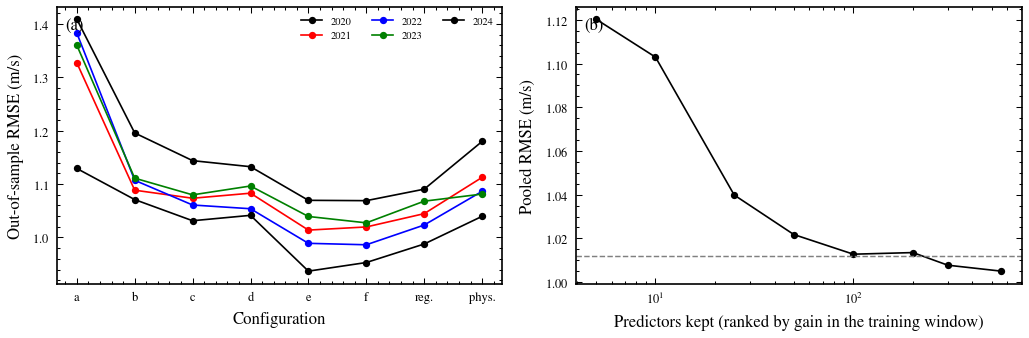

53 values written to /content/drive/MyDrive/windforecast_rev1/revision/results_10.json


In [5]:
# --- Performance versus predictor count, and Figure S5 -------------------------------------------
kk = sorted(int(r.split('_')[1]) for r in preds if r.startswith('topk_'))
fc = pd.DataFrame([dict(k=k, RMSE=ru.rmse(Y_true, preds[f'topk_{k}'])) for k in kk])
full_rmse = ru.rmse(Y_true, preds['f_full'])
within = fc[fc.RMSE <= full_rmse * 1.01]
RES.put('FC_BEST_K', int(fc.loc[fc.RMSE.idxmin(), 'k']), 'd')
RES.put('FC_SENTENCE', f'came within 1% of the full-set RMSE from k = {int(within.k.min())} predictors onward, '
        f'with the lowest error at k = {int(fc.loc[fc.RMSE.idxmin(), "k"])}' if len(within)
        else 'did not reach the full-set RMSE at any k')
fig, axs = plt.subplots(1, 2, figsize=(7.0, 2.4))
by_year = long[long.rung.isin(order)].groupby(['rung', 'outer_year']).apply(
    lambda g: ru.rmse(g.y_true, g.pred), include_groups=False).rename('RMSE').reset_index()
for Yy, g in by_year.groupby('outer_year'):
    g = g.set_index('rung').reindex(order).reset_index()
    axs[0].plot(range(len(g)), g.RMSE, 'o-', ms=2.5, lw=0.8, label=str(Yy))
axs[0].set_xticks(range(len(order)))
axs[0].set_xticklabels([names[r].split(')')[0].strip('( ') if r.startswith(('a', 'b', 'c', 'd', 'e', 'f')) else
                        ('reg.' if 'neighbour' in r else 'phys.') for r in order])
axs[0].set_ylabel('Out-of-sample RMSE (m/s)'); axs[0].set_xlabel('Configuration')
axs[0].legend(frameon=False, ncol=3, fontsize=5)
axs[1].plot(fc.k, fc.RMSE, 'o-', ms=2.5, lw=0.8)
axs[1].axhline(full_rmse, color='grey', ls='--', lw=0.7)
axs[1].set_xscale('log'); axs[1].set_xlabel('Predictors kept (ranked by gain in the training window)')
axs[1].set_ylabel('Pooled RMSE (m/s)')
for a, t in zip(axs, ['(a)', '(b)']):
    a.text(0.02, 0.92, t, transform=a.transAxes)
fig.tight_layout(); ru.savefig(fig, REV, 'figS5_ablation_featurecount'); plt.show()
by_year.to_csv(REV + 'tables/S_ablation_by_year.csv', index=False)
RES.save()
